##T-test on Real Dataset — Student Performance (Kaggle)

**Dataset:** StudentsPerformance.csv
**Download from:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

**Question:**
Are math scores of Male and Female students
significantly different?

**H0:** Male mean = Female mean
**H1:** Male mean ≠ Female mean

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv("/content/StudentsPerformance[1].csv")
print(df.head())
print(df.shape)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)


In [ ]:
male_scores   = df[df["gender"] == "male"]["math score"]
female_scores = df[df["gender"] == "female"]["math score"]

print(f"Male   → Mean: {male_scores.mean():.2f}, N: {len(male_scores)}")
print(f"Female → Mean: {female_scores.mean():.2f}, N: {len(female_scores)}")

# Check equal variance
levene_stat, levene_p = stats.levene(male_scores, female_scores)
equal_var = levene_p > 0.05
print(f"\nLevene's P-Value : {levene_p:.4f} → Equal Variance: {equal_var}")

# T-Test
t_stat, p_val = stats.ttest_ind(male_scores, female_scores, equal_var=equal_var)

print(f"\nT-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_val:.4f}")

print(f"\nResult")
if p_val < 0.05:
    print("Reject H0 ✅ → Male and Female math scores ARE significantly different")
else:
    print("Accept H0 ✅ → No significant difference between Male and Female scores")

Male   → Mean: 68.73, N: 482
Female → Mean: 63.63, N: 518

Levene's P-Value : 0.5563 → Equal Variance: True

T-Statistic : 5.3832
P-Value     : 0.0000

Result
Reject H0 ✅ → Male and Female math scores ARE significantly different


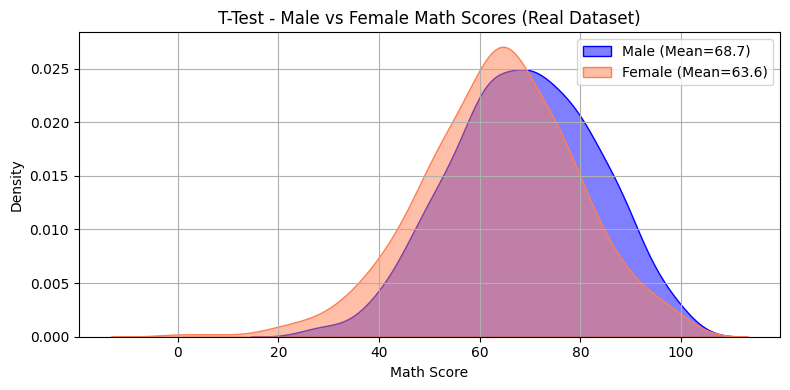

In [ ]:
plt.figure(figsize=(8, 4))

sns.kdeplot(male_scores,   fill=True, color="blue",  alpha=0.5, label=f"Male (Mean={male_scores.mean():.1f})")
sns.kdeplot(female_scores, fill=True, color="coral", alpha=0.5, label=f"Female (Mean={female_scores.mean():.1f})")

plt.title("T-Test - Male vs Female Math Scores (Real Dataset)")
plt.xlabel("Math Score")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()